# FDFK Fortran Scaling Comparison

Wall-clock scaling of the hybrid FD–FK Fortran benchmark (`test1`) from logs in
`FDFK_Scaling_Fortran/`.

**Baseline geometry** (test1_1): 200 km × 50 km domain, Δx = Δz = 200 m, Δt = 0.01 s,
t_max = 40 s → nx = 1001, nz = 251, nt = 4001.

Both suites use the same baseline grid (1001×251). Thread scaling varies OpenMP count from `test1_1`; spatial scaling varies grid size from `test1_8` (8 threads).

| Category | Directories | Varies |
|----------|-------------|--------|
| **Thread scaling** | `test1_1`, `test1_2`, `test1_4`, `test1_8`, `test1_16`, `test1_64` | OpenMP thread count (fixed grid) |
| **Spatial scaling** | `test1_8`, `test1_s2`, `test1_s4`, `test1_s8`, `test1_s16`, `test1_s32`, `test1_s64` | Grid resolution / domain size (suffix ≈ grid-point ratio vs baseline) |

Runtime is parsed by `parse_scaling_times.py`:
- Prefer **Start time** / **End time** stamps (elapsed line is garbled).
- Otherwise sum the first two `min. remained` values from progress output.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from parse_scaling_times import discover_runs, format_summary_table

EXAMPLE_DIR = Path(".").resolve()
DATA_DIR = EXAMPLE_DIR / "FDFK_Scaling_Fortran"

runs = discover_runs(DATA_DIR)
thread_runs = sorted([r for r in runs if r.threads is not None], key=lambda r: r.threads)
spatial_runs = sorted([r for r in runs if r.spatial_factor is not None], key=lambda r: r.spatial_factor)

print("Thread scaling")
print(format_summary_table(runs, key="threads"))
print()
print("Spatial scaling")
print(format_summary_table(runs, key="spatial"))

Thread scaling
Case        Threads   Time (s)     Method  Complete
---------------------------------------------------
test1_1           1     1084.6  start_end      True
test1_2           2      642.3  start_end      True
test1_4           4      365.1  start_end      True
test1_8           8      390.3  start_end      True
test1_16         16      307.5  start_end      True
test1_64         64      385.2  start_end      True

Spatial scaling
Case        Scale     nx     nz   Grid pts   Time (s)     Method  Complete
--------------------------------------------------------------------------
test1_8         1   1001    251     251251      390.3  start_end      True
test1_s2        2   1001    501     501501      665.6  start_end      True
test1_s4        4   2001    501    1002501     1782.3  start_end      True
test1_s8        8   2001   1001    2003001     2556.3  start_end      True
test1_s16      16   4001   1001    4005001     4395.7  start_end      True
test1_s32      32   4001   

## Thread scaling — strong scaling

Fixed problem size (1001 × 251 grid). **Ideal strong scaling**:

- Runtime \(T(N) \approx T_1 / N\)
- Efficiency \(E(N) = T_1 / (N \, T_N)\)

We plot measured wall time vs thread count and compare efficiency to ideal linear scaling.

In [2]:
t1 = thread_runs[0].time_seconds
threads = np.array([r.threads for r in thread_runs], dtype=float)
times = np.array([r.time_seconds for r in thread_runs])
speedup = t1 / times
efficiency = speedup / threads

thread_df = pd.DataFrame({
    "case": [r.label for r in thread_runs],
    "threads": threads.astype(int),
    "time_s": times,
    "speedup": speedup,
    "efficiency": efficiency,
    "method": [r.method for r in thread_runs],
})
thread_df

,case,threads,time_s,speedup,efficiency,method
0,test1_1,1,1084.552,1.000000,1.000000,start_end
1,test1_2,2,642.275,1.688610,0.844305,start_end
2,test1_4,4,365.135,2.970277,0.742569,start_end
3,test1_8,8,390.302,2.778751,0.347344,start_end
4,test1_16,16,307.468,3.527365,0.220460,start_end
5,test1_64,64,385.156,2.815877,0.043998,start_end


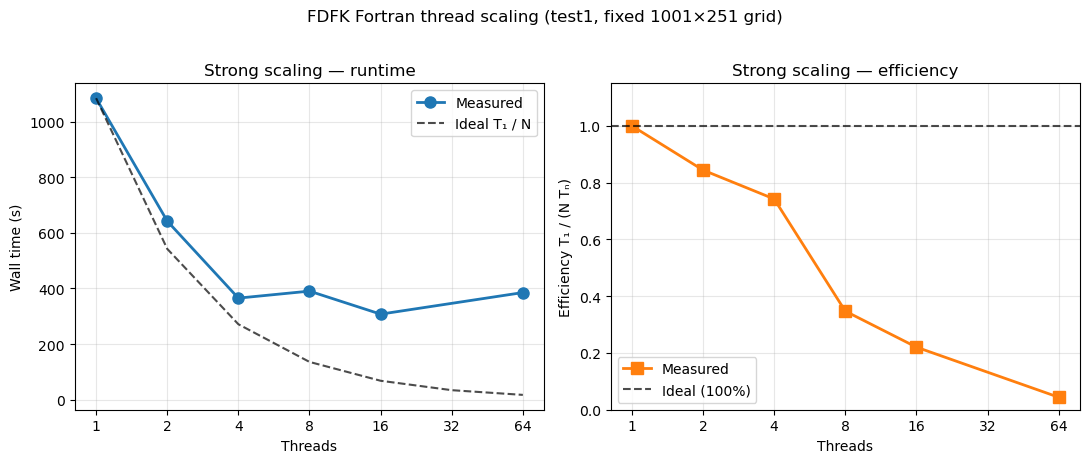

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

ideal_threads = np.array([1, 2, 4, 8, 16, 32, 64])
ideal_time = t1 / ideal_threads

ax = axes[0]
ax.plot(threads, times, "o-", label="Measured", linewidth=2, markersize=8)
ax.plot(ideal_threads, ideal_time, "k--", label="Ideal T₁ / N", alpha=0.7)
ax.set_xscale("log", base=2)
ax.set_xticks(ideal_threads)
ax.set_xticklabels([str(int(t)) for t in ideal_threads])
ax.set_xlabel("Threads")
ax.set_ylabel("Wall time (s)")
ax.set_title("Strong scaling — runtime")
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(threads, efficiency, "s-", color="C1", label="Measured", linewidth=2, markersize=8)
ax.axhline(1.0, color="k", linestyle="--", alpha=0.7, label="Ideal (100%)")
ax.set_xscale("log", base=2)
ax.set_xticks(ideal_threads)
ax.set_xticklabels([str(int(t)) for t in ideal_threads])
ax.set_xlabel("Threads")
ax.set_ylabel("Efficiency T₁ / (N Tₙ)")
ax.set_title("Strong scaling — efficiency")
ax.set_ylim(0, 1.15)
ax.legend()
ax.grid(True, alpha=0.3)

fig.suptitle("FDFK Fortran thread scaling (test1, fixed 1001×251 grid)", y=1.02)
fig.tight_layout()
fig.savefig(EXAMPLE_DIR / "thread_scaling.png", dpi=150, bbox_inches="tight")
plt.show()

## Spatial scaling — problem-size growth

Suffix `sN` indicates total grid points ≈ **N × baseline** (see nx, nz in logs).
FDFK is 2D; work per time step scales as \(O(n_x n_z)\).

**Theoretical runtime** (fixed hardware, same nt):

\[
T(N) \approx T_0 \times \frac{N_{\mathrm{grid}}}{N_0}
\]

where \(N_{\mathrm{grid}} = n_x n_z\). If both dimensions were doubled each
step (full 2D refinement), one would expect \(T \propto N_{\mathrm{grid}}^2\);
here the suffix tracks total DOFs, so linear growth in grid points is the
appropriate reference.

Runs `test1_s32` and `test1_s64` did **not** reach t = 40 s; their times use the
`remained` estimator and are marked incomplete.

In [4]:
s0 = spatial_runs[0].time_seconds
scale = np.array([r.spatial_factor for r in spatial_runs], dtype=float)
s_times = np.array([r.time_seconds for r in spatial_runs])
grid_pts = np.array([r.grid_points for r in spatial_runs])
complete = np.array([r.complete for r in spatial_runs])

spatial_df = pd.DataFrame({
    "case": [r.label for r in spatial_runs],
    "scale_factor": scale.astype(int),
    "nx": [r.nx for r in spatial_runs],
    "nz": [r.nz for r in spatial_runs],
    "grid_points": grid_pts,
    "time_s": s_times,
    "complete": complete,
    "method": [r.method for r in spatial_runs],
})
spatial_df

,case,scale_factor,nx,nz,grid_points,time_s,complete,method
0,test1_8,1,1001,251,251251,390.302,True,start_end
1,test1_s2,2,1001,501,501501,665.644,True,start_end
2,test1_s4,4,2001,501,1002501,1782.324,True,start_end
3,test1_s8,8,2001,1001,2003001,2556.346,True,start_end
4,test1_s16,16,4001,1001,4005001,4395.722,True,start_end
5,test1_s32,32,4001,2001,8006001,8167.560,False,remained
6,test1_s64,64,8001,2001,16010001,20449.860,False,remained


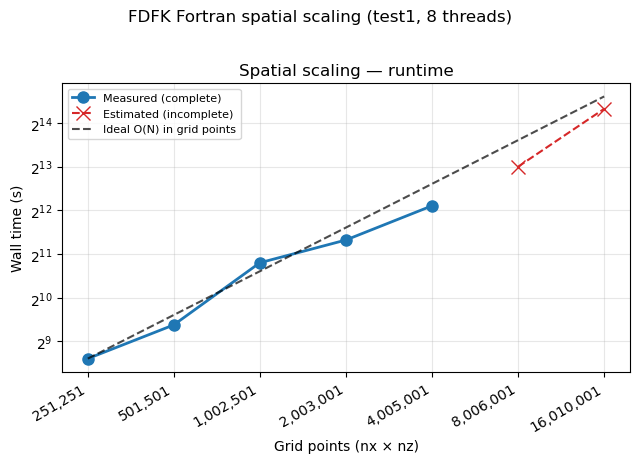

In [6]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))

g0 = grid_pts[0]
ideal_g = np.logspace(np.log2(g0), np.log2(grid_pts[-1]), 64, base=2)
ideal_time = s0 * (ideal_g / g0)
# ideal_time_quadratic = s0 * (ideal_g / g0) ** 2

ax.plot(grid_pts[complete], s_times[complete], "o-", label="Measured (complete)", linewidth=2, markersize=8)
if (~complete).any():
    ax.plot(grid_pts[~complete], s_times[~complete], "x--", color="C3", label="Estimated (incomplete)", markersize=10)
ax.plot(ideal_g, ideal_time, "k--", alpha=0.7, label="Ideal O(N) in grid points")
# ax.plot(ideal_g, ideal_time_quadratic, "k:", alpha=0.5, label="O(N²) per-dim doubling ref.")
ax.set_xscale("log", base=2)
ax.set_yscale("log", base=2)
ax.set_xticks(grid_pts)
ax.set_xticklabels([f"{int(g):,}" for g in grid_pts], rotation=30, ha="right")
ax.set_xlabel("Grid points (nx × nz)")
ax.set_ylabel("Wall time (s)")
ax.set_title("Spatial scaling — runtime")
ax.legend(fontsize=8)
ax.grid(True, which="both", alpha=0.3)

fig.suptitle("FDFK Fortran spatial scaling (test1, 8 threads)", y=1.02)
fig.tight_layout()
fig.savefig(EXAMPLE_DIR / "spatial_scaling.png", dpi=150, bbox_inches="tight")
plt.show()

## Notes

- Thread counts 8 and 64 show **lower speedup** than 4 and 16 — likely system load,
  memory bandwidth, or OpenMP overhead on the test machine.
- Spatial scaling anchors at **`test1_8`** (8 threads, 1001×251) so the reference matches the thread count used for the spatial suite; thread scaling still uses the 1-thread `test1_1` baseline.
- Spatial scaling roughly follows linear growth in grid points for complete runs,
  with some super-linear steps (e.g. s8, s16) possibly from cache effects or I/O.
- `test1_s32` stopped at t ≈ 36 s; `test1_s64` at t ≈ 14.5 s — treat their times as
  projections from early progress lines, not measured end-to-end runs.